# Прототип книжного рекомендательного сервиса (goodbooks-10k)

Лабораторный журнал решения: вызовы функций пакета `recsys` (`src/recsys`), промежуточные таблицы и графики. Постановка, обоснования и итоговые выводы — в `README.md`. Графики, используемые в README, сохраняются в `reports/figures/`.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from recsys import data, eda, plots

pd.set_option("display.float_format", "{:.4f}".format)
plots.set_style()

dataset = data.load_all()
ratings = dataset.ratings
pd.Series(data.validate(dataset), name="value").to_frame()

,value
n_ratings,5976479
n_users,53424
n_books,10000
n_tags,34252
n_book_tags,999912
book_tags_duplicate_pairs,8
book_tags_nonpositive_count,6
books_missing_original_title,585


## 1. Разведочный анализ данных (EDA)

### 1.1. Общая статистика

In [2]:
eda.summary(ratings).to_frame("value")

,value
n_ratings,5976479.0000
n_users,53424.0000
n_books,10000.0000
density,0.0112
sparsity,0.9888
rating_mean,3.9199
rating_median,4.0000
share_relevant,0.6897


Заполненность матрицы 1.12 %; дубликатов пар `(user_id, book_id)` и пропусков нет.

### 1.2. Распределение оценок

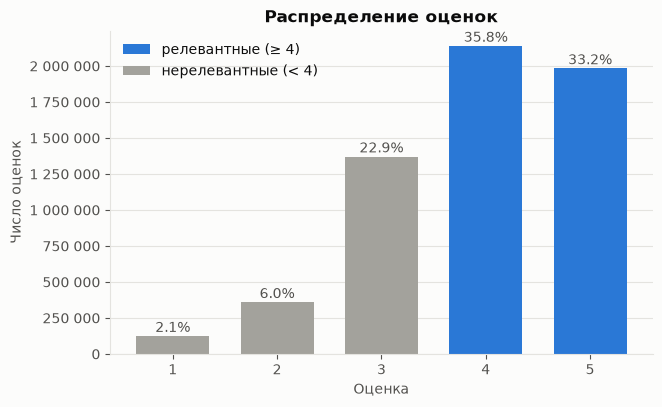

,count,share
rating,,
1,124195,0.0208
2,359257,0.0601
3,1370916,0.2294
4,2139018,0.3579
5,1983093,0.3318


In [3]:
distribution = eda.rating_distribution(ratings)
fig = plots.plot_rating_distribution(distribution)
plots.save_figure(fig, "rating_distribution")
plt.show()
distribution

Оценки 4–5 составляют 69.0 %, 1–2 — 8.1 %; при пороге 3 релевантными были бы 92 % оценок.

### 1.3. Активность пользователей

In [4]:
user_counts = eda.user_counts(ratings)
book_counts = eda.book_counts(ratings)
pd.DataFrame({"users": eda.describe_counts(user_counts), "books": eda.describe_counts(book_counts)})

,users,books
min,19.0000,8.0000
q01,40.0000,72.9900
q10,82.0000,115.0000
q25,96.0000,155.0000
median,111.0000,248.0000
q75,128.0000,503.0000
q90,146.0000,1180.3000
q99,176.0000,6305.0200
max,200.0000,22806.0000
mean,111.8688,597.6479


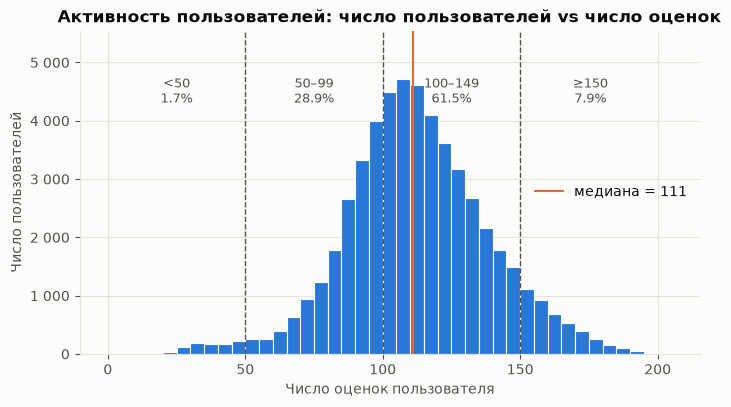

,n_users,share_users,share_ratings,mean_rating
segment,,,,
<50,899,0.0168,0.0056,3.8526
50–99,15441,0.2890,0.2221,3.9879
100–149,32849,0.6149,0.6571,3.9129
≥150,4235,0.0793,0.1152,3.8492


In [5]:
fig = plots.plot_user_activity(user_counts)
plots.save_figure(fig, "user_activity")
plt.show()
eda.user_segments(ratings)

Диапазон 19–200 оценок на пользователя, медиана 111; сегмент `<50` — 899 пользователей (1.7 %), его средняя оценка (3.85) ниже, чем у сегмента `50–99` (3.99).

### 1.4. Популярность книг и long tail

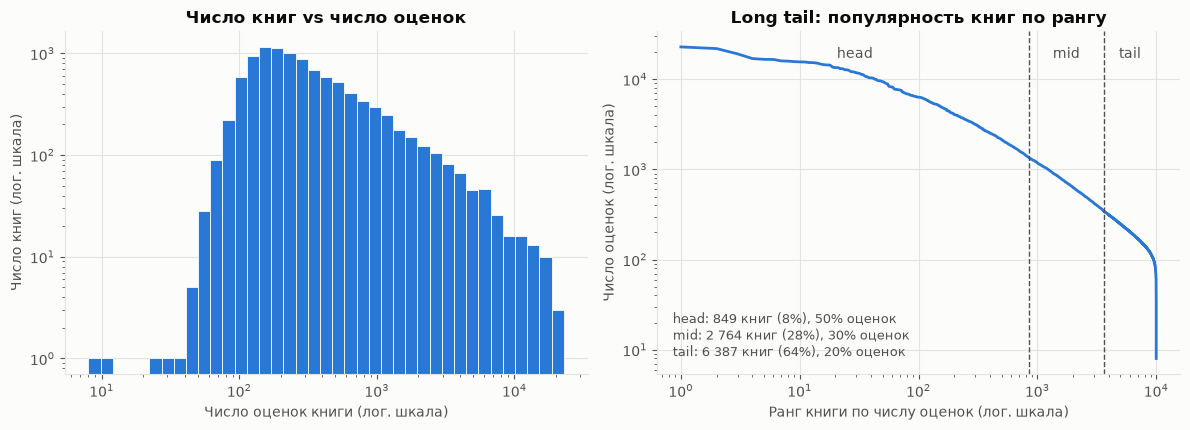

,n_books,share_books,share_ratings,min_ratings,max_ratings
segment,,,,,
head,849,0.0849,0.5001,1348,22806
mid,2764,0.2764,0.2999,346,1347
tail,6387,0.6387,0.2000,8,346


In [6]:
fig = plots.plot_book_popularity(book_counts)
plots.save_figure(fig, "book_popularity")
plt.show()
eda.popularity_table(book_counts)

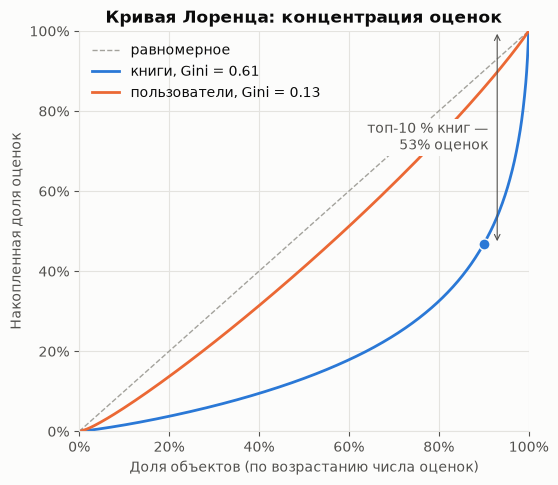

,value
top_1%,0.1709
top_10%,0.5320
top_20%,0.6750
gini_books,0.6127
gini_users,0.1293


In [7]:
fig = plots.plot_lorenz(book_counts, user_counts)
plt.show()
pd.concat(
    [
        eda.top_share(book_counts),
        pd.Series({"gini_books": eda.gini(book_counts), "gini_users": eda.gini(user_counts)}),
    ]
).to_frame("value")

Head — 849 книг (8.5 %) с 50 % оценок, long tail — 6 387 книг (63.9 %) с 20 % оценок; на топ-10 % книг приходится 53.2 % оценок.

### 1.5. Теги книг

In [8]:
usage = data.tag_usage(dataset)
raw_frequency = eda.tag_frequency(usage)
service_mask = pd.Series(
    data.is_service_tag(raw_frequency.index.to_series()).to_numpy(), index=raw_frequency.index
)
book_tags = data.clean_book_tags(dataset)
clean_frequency = eda.tag_frequency(book_tags)

service_rows = data.is_service_tag(usage["tag_name"])
pd.Series(
    {
        "raw_tags": raw_frequency.shape[0],
        "service_tags": int(service_mask.sum()),
        "service_share_rows": service_rows.mean(),
        "service_share_count": usage.loc[service_rows, "count"].sum() / usage["count"].sum(),
        "clean_tags": clean_frequency.shape[0],
        "clean_tags_per_book_median": book_tags.groupby("book_id").size().median(),
    }
).to_frame("value")

,value
raw_tags,34250.0000
service_tags,5394.0000
service_share_rows,0.4435
service_share_count,0.7996
clean_tags,28830.0000
clean_tags_per_book_median,53.0000


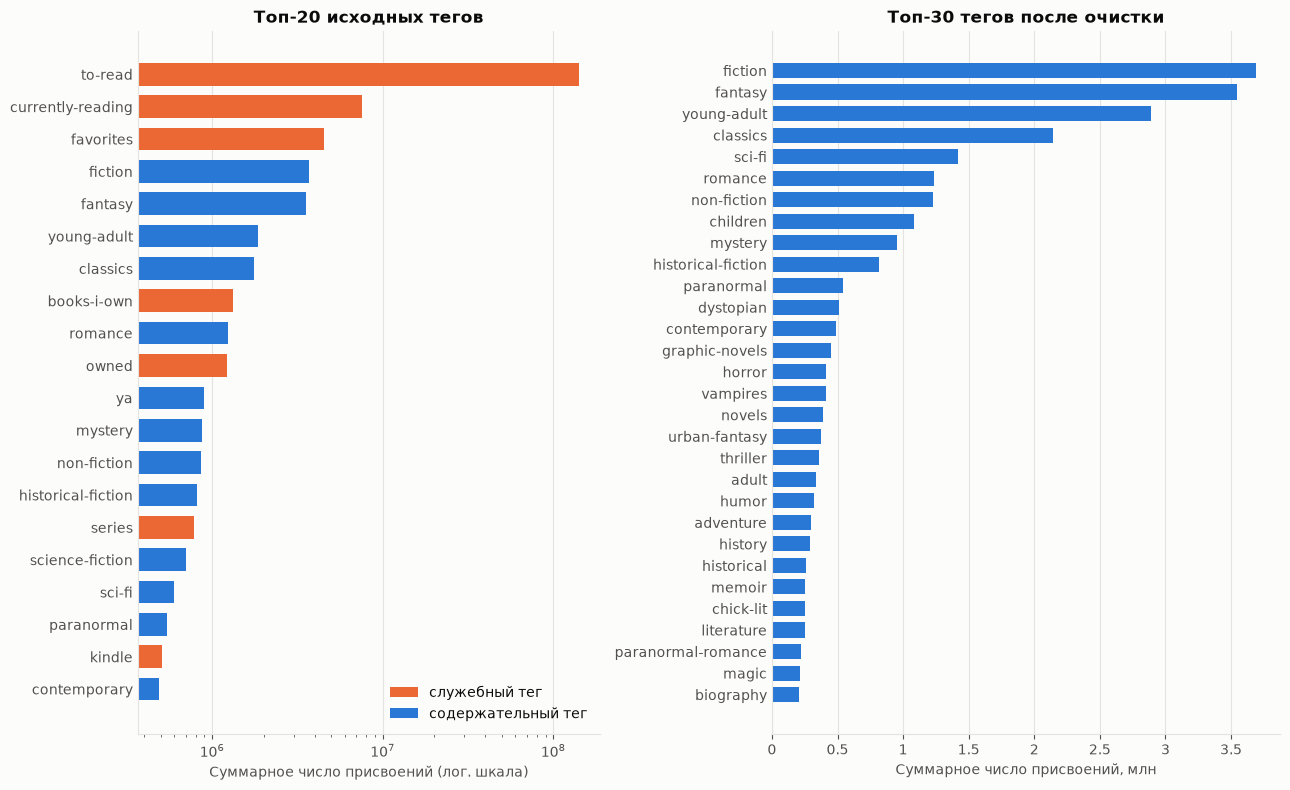

,n_books,total_count
tag_name,,
fiction,9097,3688819
fantasy,4259,3548157
young-adult,3701,2887190
classics,2854,2141495
sci-fi,2476,1420757
romance,4251,1231926
non-fiction,2153,1228950
children,1494,1081274
mystery,3693,951120


In [9]:
fig = plots.plot_top_tags(raw_frequency, service_mask, clean_frequency)
plots.save_figure(fig, "top_tags")
plt.show()
clean_frequency.head(30)

Служебные теги: 5 394 тега, 44 % записей и 80 % присвоений. После очистки — 28 830 тегов, медиана 53 тега на книгу.

### 1.6. Дополнительный анализ

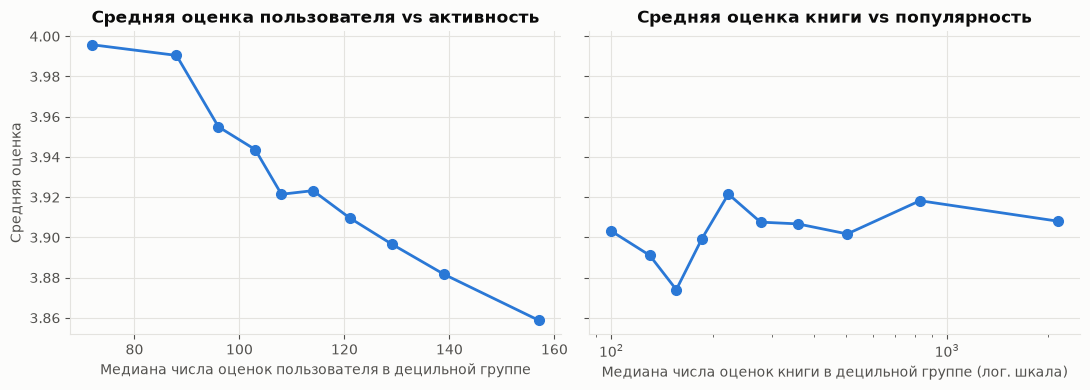

,value
sorted_by_user,False
blocks_per_user,53.6456
median_span_share,0.3153


In [10]:
users_by_activity = eda.activity_vs_rating(ratings, "user_id")
books_by_popularity = eda.activity_vs_rating(ratings, "book_id")
fig = plots.plot_activity_vs_rating(users_by_activity, books_by_popularity)
plt.show()
eda.chronology_check(ratings).to_frame("value")

Средняя оценка пользователя снижается с ростом активности (4.00 → 3.86 по децилям), средняя оценка книги от популярности практически не зависит (3.87–3.92). Оценки пользователя распределены по всему файлу (53.6 блока на пользователя, медианный размах 31.5 % длины файла) — порядок строк глобальный по времени.

## 2. Протокол оценки, Popularity, Content-Based

### 2.1. Разбиение и набор оценки

In [11]:
from recsys import config, evaluation, split
from recsys.models import ContentBased, Popularity

outer = split.temporal_split(ratings)
inner = split.temporal_split(outer.train)
parts = {"train": outer.train, "test": outer.test, "train_inner": inner.train, "valid": inner.test}
pd.DataFrame(
    {
        name: {
            "ratings": len(part),
            "users": part["user_id"].nunique(),
            "books": part["book_id"].nunique(),
            "share_relevant": (part["rating"] >= config.RELEVANCE_THRESHOLD).mean(),
        }
        for name, part in parts.items()
    }
).T

,ratings,users,books,share_relevant
train,4781208.0000,53424.0000,10000.0000,0.6913
test,1195271.0000,53424.0000,10000.0000,0.6832
train_inner,3824978.0000,53424.0000,10000.0000,0.6957
valid,956230.0000,53424.0000,9998.0000,0.6740


In [12]:
assert outer.train.index.intersection(outer.test.index).empty
assert inner.test.index.isin(outer.train.index).all()

valid_set = evaluation.build_eval_set(inner.train, inner.test)
valid_relevant = inner.test[inner.test["rating"] >= config.RELEVANCE_THRESHOLD]
pd.Series(
    {
        "users_with_relevant": valid_relevant["user_id"].nunique(),
        "eval_users": valid_set.user_ids.size,
        "n_relevant_mean": valid_set.n_relevant.mean(),
        "n_relevant_median": float(pd.Series(valid_set.n_relevant).median()),
        "catalog_in_train": valid_set.n_catalog,
    }
).to_frame("value")

,value
users_with_relevant,53160.0000
eval_users,10000.0000
n_relevant_mean,12.1514
n_relevant_median,12.0000
catalog_in_train,10000.0000


Каждый пользователь получает 20 % последних оценок в test (1 195 271 оценка), из оставшихся 80 % — ещё 20 % в valid. Подбор гиперпараметров — на valid по выборке 10 000 пользователей, test не используется.

### 2.2. Popularity

In [13]:
grid_models = [Popularity("count")]
grid_models += [
    Popularity("mean", m) for m in (1, 10, 100, 500, 1000, 2000, 5000, 7000, 8000, 10000)
]
grid_models += [Popularity("weighted", m) for m in (10, 100, 1000, 10000, 100000, 1000000)]
columns = ["precision", "recall", "ndcg", "hit_rate", "coverage", "novelty", "short_lists"]
rows = []
for model in grid_models:
    result = evaluation.evaluate(model.fit(inner.train), valid_set, ks=(10,)).iloc[0]
    rows.append(
        {
            "method": model.method,
            "min_ratings": model.min_ratings,
            "n_candidates": model.n_candidates,
            **result[columns],
        }
    )
popularity_grid = pd.DataFrame(rows)
popularity_grid

,method,min_ratings,n_candidates,precision,recall,ndcg,hit_rate,coverage,novelty,short_lists
0,count,0,10000,0.0348,0.0291,0.0383,0.2076,0.0047,8.1939,0.0000
1,mean,1,10000,0.0006,0.0005,0.0005,0.0053,0.0015,17.6030,0.0000
2,mean,10,9925,0.0008,0.0007,0.0009,0.0063,0.0017,15.5694,0.0000
3,mean,100,6742,0.0016,0.0014,0.0017,0.0136,0.0020,14.1711,0.0000
4,mean,500,1520,0.0081,0.0065,0.0071,0.0694,0.0017,11.6505,0.0000
5,mean,1000,720,0.0114,0.0095,0.0110,0.1009,0.0022,10.9394,0.0000
6,mean,2000,307,0.0280,0.0233,0.0265,0.1624,0.0028,9.2705,0.0000
7,mean,5000,81,0.0353,0.0295,0.0391,0.2031,0.0040,8.5952,0.0000
8,mean,7000,49,0.0386,0.0323,0.0417,0.2134,0.0040,8.4578,0.0000
9,mean,8000,37,0.0387,0.0324,0.0425,0.2015,0.0037,8.3197,0.0022


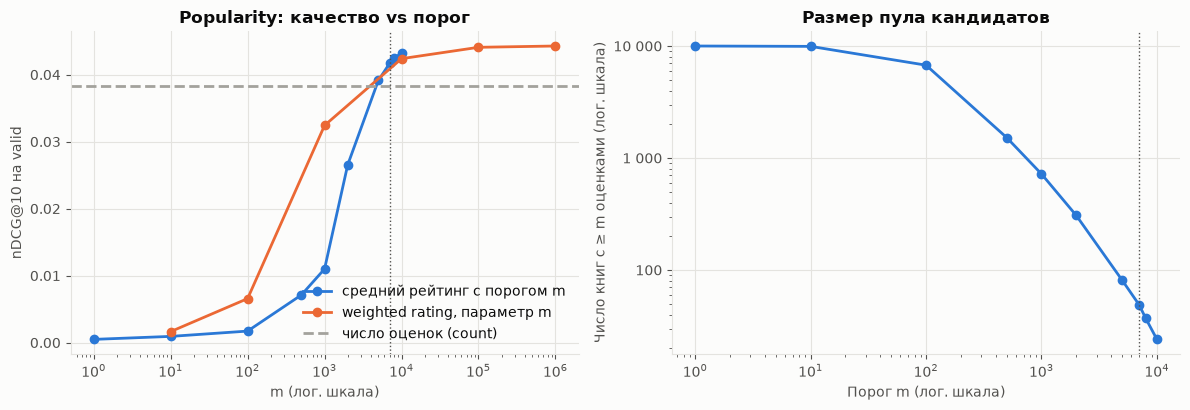

In [14]:
count_ndcg = popularity_grid.loc[popularity_grid["method"] == "count", "ndcg"].item()
fig = plots.plot_popularity_threshold(popularity_grid, count_ndcg, config.POPULARITY_MIN_RATINGS)
plt.show()

Без порога top-10 по среднему рейтингу состоит из книг с единичными оценками 5 (nDCG@10 < 0.001). С ростом порога nDCG@10 растёт; порог выбирается как максимум nDCG@10 при полных списках top-10 (`short_lists` = 0): m = 7 000, пул — 49 книг. При m ≥ 8 000 пула не хватает для части пользователей. Weighted rating выходит на плато 0.044 при m ≥ 10⁵, т.е. при m ≫ v ранжирование по Σ(r − C).

In [15]:
popularity_mean = Popularity("mean", config.POPULARITY_MIN_RATINGS).fit(inner.train)
popularity_mean.top_n(dataset.books, 10)

,book_id,title,authors,n_ratings,mean_rating,score
0,25,Harry Potter and the Deathly Hallows (Harry Po...,"J.K. Rowling, Mary GrandPré",11301,4.5305,4.5305
1,27,Harry Potter and the Half-Blood Prince (Harry ...,"J.K. Rowling, Mary GrandPré",11117,4.4444,4.4444
2,24,Harry Potter and the Goblet of Fire (Harry Pot...,"J.K. Rowling, Mary GrandPré",11536,4.4343,4.4343
3,18,Harry Potter and the Prisoner of Azkaban (Harr...,"J.K. Rowling, Mary GrandPré, Rufus Beck",11885,4.4172,4.4172
4,31,The Help,Kathryn Stockett,9669,4.4031,4.4031
5,39,"A Game of Thrones (A Song of Ice and Fire, #1)",George R.R. Martin,7708,4.3732,4.3732
6,2,Harry Potter and the Sorcerer's Stone (Harry P...,"J.K. Rowling, Mary GrandPré",18807,4.3689,4.3689
7,21,Harry Potter and the Order of the Phoenix (Har...,"J.K. Rowling, Mary GrandPré",11327,4.3646,4.3646
8,4,To Kill a Mockingbird,Harper Lee,15772,4.3392,4.3392
9,47,The Book Thief,Markus Zusak,7017,4.3256,4.3256


### 2.3. Content-Based

In [16]:
content = ContentBased(dataset.books, book_tags)
pd.Series(
    {
        "vocabulary": len(content.vectorizer.vocabulary_),
        "nnz": content.item_vectors.nnz,
        "density": content.item_vectors.nnz
        / (content.item_vectors.shape[0] * content.item_vectors.shape[1]),
        "profile_example": content.profiles.loc[2][:300],
    }
).to_frame("value")

,value
vocabulary,16836
nnz,526662
density,0.0031
profile_example,Harry Potter and the Philosopher's Stone fanta...


In [17]:
content_grid = pd.concat(
    [
        evaluation.evaluate(
            ContentBased(dataset.books, book_tags, n).fit(inner.train), valid_set, ks=(10,)
        )
        for n in (5, 10, 20, 50, None)
    ]
)
content_grid[columns]

,,precision,recall,ndcg,hit_rate,coverage,novelty,short_lists
model,k,,,,,,,
Content-Based[tags=5],10,0.0143,0.0129,0.0160,0.1076,0.2292,13.8946,0.0000
Content-Based[tags=10],10,0.0216,0.0192,0.0233,0.1529,0.3510,13.8900,0.0000
Content-Based[tags=20],10,0.0340,0.0301,0.0377,0.2292,0.4663,13.0144,0.0000
Content-Based[tags=50],10,0.0467,0.0404,0.0530,0.2925,0.4928,12.1800,0.0000
Content-Based[tags=all],10,0.0474,0.0411,0.0536,0.2943,0.4881,12.1374,0.0000


Качество растёт с числом тегов в профиле до ~50 и далее не меняется (nDCG@10 0.016 при 5 тегах, 0.054 при всех); используются все очищенные теги.

In [18]:
queries = [2, 1, 10, 7]
pd.concat(
    {
        dataset.books.loc[book_id - 1, "title"]: content.get_similar_books(book_id, n=5)
        for book_id in queries
    },
    names=["query", "rank"],
)

book_id  \
query                                              rank            
Harry Potter and the Sorcerer's Stone (Harry Po... 0          23   
                                                   1          18   
                                                   2          24   
                                                   3          25   
                                                   4          27   
The Hunger Games (The Hunger Games, #1)            0          17   
                                                   1          20   
                                                   2         507   
                                                   3          12   
                                                   4         327   
Pride and Prejudice                                0         171   
                                                   1         230   
                                                   2         471   
                                                   3         451   
                                                   4          63   
The Hobbit                                         0         189   
                                                   1         611   
                                                   2         155   
                                                   3         161   
                                                   4         466   

                                                                                                     title  \
query                                              rank                                                      
Harry Potter and the Sorcerer's Stone (Harry Po... 0     Harry Potter and the Chamber of Secrets (Harry...   
                                                   1     Harry Potter and the Prisoner of Azkaban (Harr...   
                                                   2     Harry Potter and the Goblet of Fire (Harry Pot...   
                                                   3     Harry Potter and the Deathly Hallows (Harry Po...   
                                                   4     Harry Potter and the Half-Blood Prince (Harry ...   
The Hunger Games (The Hunger Games, #1)            0                  Catching Fire (The Hunger Games, #2)   
                                                   1                     Mockingjay (The Hunger Games, #3)   
                                                   2     The Hunger Games Trilogy Boxset (The Hunger Ga...   
                                                   3                             Divergent (Divergent, #1)   
                                                   4                                   Legend (Legend, #1)   
Pride and Prejudice                                0                                                  Emma   
                                                   1                                            Persuasion   
                                                   2                                        Mansfield Park   
                                                   3                                      Northanger Abbey   
                                                   4                                     Wuthering Heights   
The Hobbit                                         0     The Lord of the Rings (The Lord of the Rings, ...   
                                                   1              The Silmarillion (Middle-Earth Universe)   
                                                   2            The Two Towers (The Lord of the Rings, #2)   
                                                   3     The Return of the King (The Lord of the Rings,...   
                                                   4                             The Hobbit: Graphic Novel   

                                                                                                   authors  \
query                        

Похожие книги — продолжения серии, книги того же автора и жанра (для «The Hunger Games» — «Divergent», «Legend»). Название усиливает близость внутри серии, теги — жанровую близость.

### 2.4. Сравнение на valid

In [19]:
content.fit(inner.train)
popularity_weighted = Popularity("weighted", config.POPULARITY_WR_M).fit(inner.train)
popularity_count = Popularity("count").fit(inner.train)
valid_comparison = evaluation.compare(
    [popularity_mean, popularity_weighted, popularity_count, content], valid_set
)
valid_comparison

precision  recall   ndcg    map  hit_rate  \
model                          k                                               
Popularity[mean, m=7000]       5      0.0416  0.0173 0.0425 0.0293    0.1172   
                               10     0.0386  0.0323 0.0417 0.0208    0.2134   
                               20     0.0326  0.0547 0.0480 0.0190    0.3399   
Popularity[weighted, m=100000] 5      0.0465  0.0197 0.0485 0.0305    0.1455   
                               10     0.0386  0.0323 0.0441 0.0219    0.2038   
                               20     0.0309  0.0518 0.0485 0.0195    0.3220   
Popularity[count]              5      0.0346  0.0147 0.0377 0.0205    0.1398   
                               10     0.0348  0.0291 0.0383 0.0159    0.2076   
                               20     0.0314  0.0523 0.0457 0.0163    0.3017   
Content-Based[tags=all]        5      0.0540  0.0239 0.0564 0.0327    0.1959   
                               10     0.0474  0.0411 0.0536 0.0238    0.2943   
                               20     0.0400  0.0684 0.0612 0.0229    0.4146   

                                   coverage  novelty  mean_popularity  \
model                          k                                        
Popularity[mean, m=7000]       5     0.0029   8.4682       11009.9738   
                               10    0.0040   8.4578       11352.2268   
                               20    0.0049   8.5389       10664.1927   
Popularity[weighted, m=100000] 5     0.0029   8.1780       13665.2763   
                               10    0.0039   8.3973       11839.1849   
                               20    0.0057   8.7730        9581.9668   
Popularity[count]              5     0.0038   8.0212       14958.4906   
                               10    0.0047   8.1939       13296.4809   
                               20    0.0071   8.3541       11916.8372   
Content-Based[tags=all]        5     0.3666  12.0048        2449.9687   
                               10    0.4881  12.1374        2226.5077   
                               20    0.6230  12.3004        1973.2057   

                                   short_lists  seconds  
model                          k                         
Popularity[mean, m=7000]       5        0.0000   1.2009  
                               10       0.0000   1.2009  
                               20       0.0063   1.2009  
Popularity[weighted, m=100000] 5        0.0000   1.3446  
                               10       0.0000   1.3446  
                               20       0.0000   1.3446  
Popularity[count]              5        0.0000   1.3306  
                               10       0.0000   1.3306  
                               20       0.0000   1.3306  
Content-Based[tags=all]        5        0.0000   7.7477  
                               10       0.0000   7.7477  
                               20       0.0000   7.7477

На valid Content-Based превосходит все варианты Popularity по точности (nDCG@10 0.054 против 0.038–0.044) и по Coverage@10 (≈ 49 % каталога против < 1 %).

## 3. Item-based Collaborative Filtering

### 3.1. Матрица схожести

In [20]:
import time
import tracemalloc

import numpy as np

from recsys import metrics
from recsys.models import ItemCF
from recsys.models.item_cf import sparse_nbytes

MB = 2**20
tracemalloc.start()
start = time.perf_counter()
item_cf = ItemCF().fit(inner.train)
item_cf_fit_seconds = time.perf_counter() - start
_, item_cf_fit_peak = tracemalloc.get_traced_memory()
tracemalloc.stop()

train_inner_matrix = data.interaction_matrix(inner.train)
n_pairs = config.N_BOOKS**2
pd.Series(
    {
        "fit_seconds": item_cf_fit_seconds,
        "fit_peak_mb": item_cf_fit_peak / MB,
        "ratings_csr_mb": sparse_nbytes(train_inner_matrix) / MB,
        "ratings_dense_float32_mb": config.N_USERS * config.N_BOOKS * 4 / MB,
        "similarity_nnz": item_cf.similarity.nnz,
        "similarity_density": item_cf.similarity.nnz / n_pairs,
        "similarity_csr_mb": sparse_nbytes(item_cf.similarity) / MB,
        "similarity_dense_float32_mb": n_pairs * 4 / MB,
        "neighbors_csr_mb": sparse_nbytes(item_cf.neighbors) / MB,
    }
).to_frame("value")

,value
fit_seconds,11.6710
fit_peak_mb,1152.3732
ratings_csr_mb,29.3861
ratings_dense_float32_mb,2037.9639
similarity_nnz,16809942.0000
similarity_density,0.1681
similarity_csr_mb,128.2878
similarity_dense_float32_mb,381.4697
neighbors_csr_mb,3.8525


In [21]:
co_counts = (train_inner_matrix[:, :1000] != 0).T.astype("float32") @ (train_inner_matrix != 0)
co_counts = co_counts.toarray().ravel()
pd.Series(
    {
        "share_pairs_with_common_users": (co_counts > 0).mean(),
        "median_common_users": float(pd.Series(co_counts[co_counts > 0]).median()),
        "share_pairs_below_5_common_users": ((co_counts > 0) & (co_counts < 5)).mean()
        / (co_counts > 0).mean(),
    },
    name="первые 1 000 книг",
).to_frame()

,первые 1 000 книг
share_pairs_with_common_users,0.7418
median_common_users,5.0000
share_pairs_below_5_common_users,0.4950


Схожесть считается блоками по 1 000 книг за 12 с; плотная матрица «пользователь × книга» (2.0 ГБ в float32) не создаётся. Положительна схожесть у 16.8 % пар книг: CSR — 128 МБ против 381 МБ в плотном виде, top-50 соседей — 3.9 МБ. Даже среди книг с `book_id` ≤ 1 000 (самые популярные) у 49.5 % пар с общими читателями таких читателей меньше 5 — схожести этих пар шумные, отсюда shrinkage.

### 3.2. Подбор параметров на valid

In [22]:
valid_users = inner.test["user_id"].to_numpy()
valid_books = inner.test["book_id"].to_numpy()
valid_ratings = inner.test["rating"].to_numpy()
rows = []
for kind in ("cosine", "adjusted_cosine", "pearson"):
    for shrinkage in (0, 10, 50, 100):
        model = ItemCF(kind, n_neighbors=10, shrinkage=shrinkage).fit(inner.train)
        for k in (10, 20, 50, 100, 200):
            model.set_n_neighbors(k)
            prediction = model.predict(valid_users, valid_books)
            result = evaluation.evaluate(model, valid_set, ks=(10,)).iloc[0]
            rows.append(
                {
                    "similarity": kind,
                    "shrinkage": shrinkage,
                    "k": k,
                    "rmse": metrics.rmse(valid_ratings, prediction),
                    "mae": metrics.mae(valid_ratings, prediction),
                    **result[columns],
                }
            )
item_cf_grid = pd.DataFrame(rows)
item_cf_grid.pivot_table(index=["similarity", "shrinkage"], columns="k", values=["rmse", "ndcg"])

ndcg                               rmse         \
k                            10     20     50     100    200    10     20    
similarity      shrinkage                                                    
adjusted_cosine 0         0.0936 0.0934 0.0943 0.0948 0.0956 0.8725 0.8602   
                10        0.0950 0.0950 0.0958 0.0964 0.0966 0.8775 0.8650   
                50        0.0959 0.0965 0.0968 0.0968 0.0970 0.8847 0.8724   
                100       0.0956 0.0958 0.0958 0.0956 0.0955 0.8885 0.8765   
cosine          0         0.0843 0.0825 0.0809 0.0806 0.0793 0.9076 0.8932   
                10        0.0847 0.0831 0.0809 0.0803 0.0788 0.9127 0.8976   
                50        0.0844 0.0825 0.0801 0.0789 0.0773 0.9183 0.9023   
                100       0.0835 0.0814 0.0793 0.0778 0.0758 0.9209 0.9046   
pearson         0         0.0857 0.0865 0.0852 0.0841 0.0839 0.8883 0.8768   
                10        0.0872 0.0879 0.0869 0.0861 0.0854 0.8932 0.8814   
                50        0.0889 0.0895 0.0876 0.0865 0.0858 0.8995 0.8869   
                100       0.0890 0.0892 0.0875 0.0858 0.0845 0.9026 0.8897   

                                                
k                            50     100    200  
similarity      shrinkage                       
adjusted_cosine 0         0.8577 0.8577 0.8577  
                10        0.8624 0.8624 0.8624  
                50        0.8699 0.8699 0.8699  
                100       0.8740 0.8740 0.8740  
cosine          0         0.8854 0.8846 0.8846  
                10        0.8894 0.8885 0.8885  
                50        0.8938 0.8930 0.8930  
                100       0.8960 0.8952 0.8952  
pearson         0         0.8743 0.8745 0.8745  
                10        0.8778 0.8779 0.8779  
                50        0.8826 0.8825 0.8825  
                100       0.8850 0.8849 0.8849

In [23]:
item_cf_grid.nlargest(5, "ndcg")

,similarity,shrinkage,k,rmse,mae,precision,recall,ndcg,hit_rate,coverage,novelty,short_lists
34,adjusted_cosine,50,200,0.8699,0.6541,0.0842,0.0734,0.0970,0.4324,0.3898,10.6633,0.0000
32,adjusted_cosine,50,50,0.8699,0.6541,0.0842,0.0734,0.0968,0.4265,0.4086,10.8430,0.0000
33,adjusted_cosine,50,100,0.8699,0.6541,0.0842,0.0734,0.0968,0.4324,0.3975,10.7370,0.0000
29,adjusted_cosine,10,200,0.8624,0.6514,0.0839,0.0731,0.0966,0.4319,0.4786,11.0982,0.0000
31,adjusted_cosine,50,20,0.8724,0.6550,0.0843,0.0734,0.0965,0.4274,0.4300,11.0397,0.0000


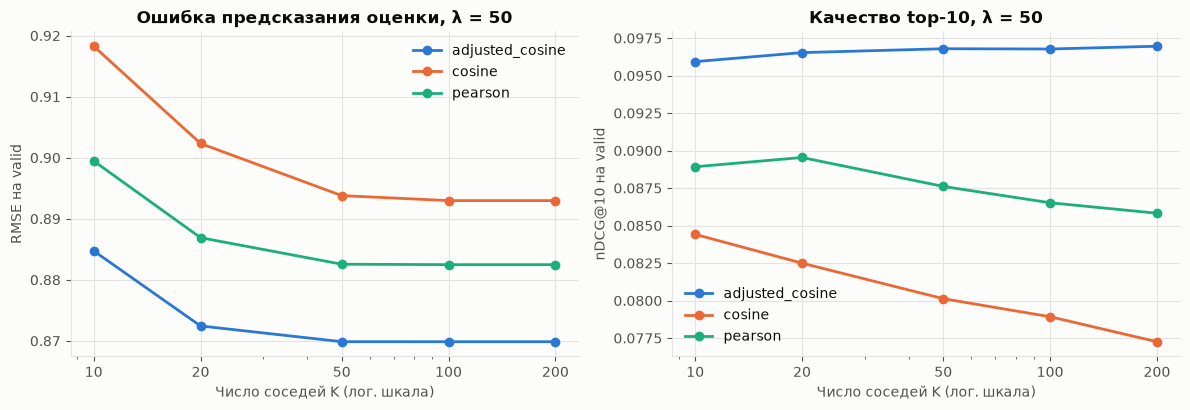

In [24]:
fig = plots.plot_item_cf_grid(item_cf_grid, config.ITEM_CF_SHRINKAGE)
plt.show()

Adjusted cosine лучше cosine и Pearson при всех λ и K: учёт смещения пользователя снижает RMSE на 0.02–0.04 и повышает nDCG@10 на 0.01–0.02 относительно cosine. Shrinkage улучшает top-N (nDCG@10 0.0948 → 0.0968 при λ = 0 → 50, K = 100) и ухудшает RMSE (0.858 → 0.870), λ = 100 хуже λ = 50 по обеим метрикам. Выбор по nDCG@10: adjusted cosine, λ = 50, K = 50 (0.0968; K = 200 даёт 0.0970 при меньшем Coverage@10). RMSE не меняется при K ≥ 50: у пользователя в train_inner в среднем 72 оценки, и большее K почти не расширяет множество соседей.

In [25]:
rows = []
for kind in ("adjusted_cosine", "pearson"):
    for use_negative, centered in ((False, True), (True, True), (True, False)):
        model = ItemCF(
            kind,
            shrinkage=config.ITEM_CF_SHRINKAGE,
            centered=centered,
            use_negative=use_negative,
        ).fit(inner.train)
        for k in (20, 50, 100):
            model.set_n_neighbors(k)
            prediction = model.predict(valid_users, valid_books)
            rows.append(
                {
                    "similarity": kind,
                    "variant": f"negative={use_negative}, centered={centered}",
                    "k": k,
                    "rmse": metrics.rmse(valid_ratings, prediction),
                }
            )
pd.DataFrame(rows).pivot_table(index=["similarity", "variant"], columns="k", values="rmse")

k                                                20     50     100
similarity      variant                                           
adjusted_cosine negative=False, centered=True 0.8724 0.8699 0.8699
                negative=True, centered=False 2.4801 2.6115 2.6279
                negative=True, centered=True  0.8690 0.8626 0.8623
pearson         negative=False, centered=True 0.8869 0.8826 0.8825
                negative=True, centered=False 1.0338 1.0670 1.0722
                negative=True, centered=True  0.8857 0.8806 0.8804

Без центрирования отрицательные схожести ломают предсказание (RMSE 2.5–2.6 для adjusted cosine): слагаемое s·r_uj при s < 0 вычитает сырую оценку. С центрированием их учёт снижает RMSE с 0.870 до 0.862 (K ≥ 50), но удваивает объём матрицы схожести и не влияет на top-N, где используются только положительные соседи. Основной вариант — положительные схожести; при них формулы с центрированием и без совпадают.

In [26]:
ranking_models = [item_cf] + [
    ItemCF(ranking="rating", min_support=support).fit(inner.train) for support in (1, 5, 10, 20)
]
pd.concat([evaluation.evaluate(model, valid_set, ks=(10,)) for model in ranking_models])[columns]

,,precision,recall,ndcg,hit_rate,coverage,novelty,short_lists
model,k,,,,,,,
"Item-CF[adjusted_cosine, K=50, λ=50, similarity]",10,0.0842,0.0734,0.0968,0.4265,0.4086,10.8430,0.0000
"Item-CF[adjusted_cosine, K=50, λ=50, rating, support=1]",10,0.0036,0.0029,0.0038,0.0319,0.9562,14.0606,0.0000
"Item-CF[adjusted_cosine, K=50, λ=50, rating, support=5]",10,0.0178,0.0167,0.0198,0.1368,0.9372,13.8026,0.0009
"Item-CF[adjusted_cosine, K=50, λ=50, rating, support=10]",10,0.0331,0.0288,0.0374,0.2298,0.8549,12.8232,0.1446
"Item-CF[adjusted_cosine, K=50, λ=50, rating, support=20]",10,0.0074,0.0055,0.0098,0.0449,0.2727,3.3413,0.9465


Ранжирование по предсказанной оценке уступает сумме схожестей в 2.6–25 раз по nDCG@10 (0.004–0.037 против 0.097): максимальную оценку получают книги с малым числом соседей и высокими оценками — нишевые книги (Novelty@10 до 14 бит). Порог поддержки частично это исправляет (лучший — 10 соседей), но при пороге 20 у 95 % пользователей список короче 10. Для top-N используется сумма схожестей с книгами, оценёнными на 4–5.

### 3.3. Сравнение на valid

In [27]:
user_mean = inner.train.groupby("user_id")["rating"].mean()
item_mean = inner.train.groupby("book_id")["rating"].mean()
start = time.perf_counter()
item_cf_prediction = item_cf.predict(valid_users, valid_books)
item_cf_predict_seconds = time.perf_counter() - start
rating_baselines = {
    "global mean": np.full(valid_ratings.size, inner.train["rating"].mean()),
    "user mean": user_mean.reindex(valid_users).to_numpy(),
    "item mean": item_mean.reindex(valid_books).to_numpy(),
    item_cf.name: item_cf_prediction,
}
pd.DataFrame(
    {
        name: {"rmse": metrics.rmse(valid_ratings, pred), "mae": metrics.mae(valid_ratings, pred)}
        for name, pred in rating_baselines.items()
    }
).T

,rmse,mae
global mean,0.9880,0.7594
user mean,0.9052,0.7049
item mean,0.9517,0.7567
"Item-CF[adjusted_cosine, K=50, λ=50, similarity]",0.8699,0.6541


In [28]:
item_cf_valid = evaluation.evaluate(item_cf, valid_set)
valid_comparison = pd.concat([valid_comparison, item_cf_valid])
valid_comparison.xs(10, level="k")[columns]

,precision,recall,ndcg,hit_rate,coverage,novelty,short_lists
model,,,,,,,
"Popularity[mean, m=7000]",0.0386,0.0323,0.0417,0.2134,0.0040,8.4578,0.0000
"Popularity[weighted, m=100000]",0.0386,0.0323,0.0441,0.2038,0.0039,8.3973,0.0000
Popularity[count],0.0348,0.0291,0.0383,0.2076,0.0047,8.1939,0.0000
Content-Based[tags=all],0.0474,0.0411,0.0536,0.2943,0.4881,12.1374,0.0000
"Item-CF[adjusted_cosine, K=50, λ=50, similarity]",0.0842,0.0734,0.0968,0.4265,0.4086,10.8430,0.0000


In [29]:
item_cf_valid

precision  recall   ndcg  \
model                                            k                              
Item-CF[adjusted_cosine, K=50, λ=50, similarity] 5      0.0980  0.0433 0.1033   
                                                 10     0.0842  0.0734 0.0968   
                                                 20     0.0690  0.1180 0.1083   

                                                       map  hit_rate  \
model                                            k                     
Item-CF[adjusted_cosine, K=50, λ=50, similarity] 5  0.0665    0.3020   
                                                 10 0.0489    0.4265   
                                                 20 0.0463    0.5865   

                                                     coverage  novelty  \
model                                            k                       
Item-CF[adjusted_cosine, K=50, λ=50, similarity] 5     0.3167  10.7975   
                                                 10    0.4086  10.8430   
                                                 20    0.5188  10.9287   

                                                     mean_popularity  \
model                                            k                     
Item-CF[adjusted_cosine, K=50, λ=50, similarity] 5         5048.0679   
                                                 10        4802.7735   
                                                 20        4400.9423   

                                                     short_lists  seconds  
model                                            k                         
Item-CF[adjusted_cosine, K=50, λ=50, similarity] 5        0.0000   1.6925  
                                                 10       0.0000   1.6925  
                                                 20       0.0000   1.6925

Item-CF — лучшая модель на valid: nDCG@10 0.097 против 0.054 у Content-Based (+81 %) и 0.044 у лучшего варианта Popularity, HitRate@10 — 42.7 %. Coverage@10 (40.9 %) ниже, чем у Content-Based (48.8 %), средняя популярность рекомендаций — 4 803 оценки против 2 227. RMSE 0.870 — на 3.9 % ниже предсказания средним пользователя (0.905).

### 3.4. Примеры выдачи

In [30]:
pd.concat(
    {
        dataset.books.loc[book_id - 1, "title"]: item_cf.get_similar_books(
            book_id, dataset.books, n=5
        )
        for book_id in queries
    },
    names=["query", "rank"],
)

book_id  \
query                                              rank            
Harry Potter and the Sorcerer's Stone (Harry Po... 0          18   
                                                   1          23   
                                                   2          24   
                                                   3          27   
                                                   4          25   
The Hunger Games (The Hunger Games, #1)            0          17   
                                                   1           2   
                                                   2          20   
                                                   3          31   
                                                   4          25   
Pride and Prejudice                                0          76   
                                                   1          43   
                                                   2         171   
                                                   3         230   
                                                   4           4   
The Hobbit                                         0          19   
                                                   1         155   
                                                   2         161   
                                                   3         189   
                                                   4         466   

                                                                                                     title  \
query                                              rank                                                      
Harry Potter and the Sorcerer's Stone (Harry Po... 0     Harry Potter and the Prisoner of Azkaban (Harr...   
                                                   1     Harry Potter and the Chamber of Secrets (Harry...   
                                                   2     Harry Potter and the Goblet of Fire (Harry Pot...   
                                                   3     Harry Potter and the Half-Blood Prince (Harry ...   
                                                   4     Harry Potter and the Deathly Hallows (Harry Po...   
The Hunger Games (The Hunger Games, #1)            0                  Catching Fire (The Hunger Games, #2)   
                                                   1     Harry Potter and the Sorcerer's Stone (Harry P...   
                                                   2                     Mockingjay (The Hunger Games, #3)   
                                                   3                                              The Help   
                                                   4     Harry Potter and the Deathly Hallows (Harry Po...   
Pride and Prejudice                                0                                 Sense and Sensibility   
                                                   1                                             Jane Eyre   
                                                   2                                                  Emma   
                                                   3                                            Persuasion   
                                                   4                                 To Kill a Mockingbird   
The Hobbit                                         0     The Fellowship of the Ring (The Lord of the Ri...   
                                                   1            The Two Towers (The Lord of the Rings, #2)   
                                                   2     The Return of the King (The Lord of the Rings,...   
                                                   3     The Lord of the Rings (The Lord of the Rings, ...   
                                                   4                             The Hobbit: Graphic Novel   

                                                                                                   authors  \
query                        

In [31]:
example_user = int(valid_set.user_ids[0])
history = (
    inner.train[inner.train["user_id"] == example_user]
    .merge(dataset.books[["book_id", "title"]], on="book_id")
    .sort_values("rating", ascending=False)
)
display(history.head(10)[["book_id", "title", "rating"]])
item_cf.get_recommendations(example_user, dataset.books, n=5, exclude=valid_set.seen)

,book_id,title,rating
0,258,The Shadow of the Wind (The Cemetery of Forgot...,5
29,1521,"Antigone (The Theban Plays, #3)",5
30,70,"Ender's Game (Ender's Saga, #1)",5
40,2002,The Death of Ivan Ilych,5
20,35,The Alchemist,5
43,1041,The Idiot,5
17,136,Divine Secrets of the Ya-Ya Sisterhood,5
44,45,Life of Pi,5
15,1644,Peace Like a River,5
14,11,The Kite Runner,5


,book_id,title,authors,score
0,1,"The Hunger Games (The Hunger Games, #1)",Suzanne Collins,0.5443
1,76,Sense and Sensibility,"Jane Austen, Tony Tanner, Ros Ballaster",0.5127
2,2,Harry Potter and the Sorcerer's Stone (Harry P...,"J.K. Rowling, Mary GrandPré",0.4867
3,25,Harry Potter and the Deathly Hallows (Harry Po...,"J.K. Rowling, Mary GrandPré",0.4796
4,14,Animal Farm,George Orwell,0.4551


Похожие по оценкам книги — продолжения серий и книги того же автора, а также популярные книги с общей аудиторией (для «The Hunger Games» — «Harry Potter», «The Help»): схожесть отражает совместное чтение, а не содержание. Рекомендации примера — книги из head каталога, хотя история пользователя состоит из классики и современной прозы.

### 3.5. Время и память

In [32]:
pd.Series(
    {
        "fit_seconds": item_cf_fit_seconds,
        "predict_valid_pairs": valid_ratings.size,
        "predict_seconds": item_cf_predict_seconds,
        "top20_users": valid_set.user_ids.size,
        "top20_seconds": item_cf_valid["seconds"].iloc[0],
    }
).to_frame("value")

,value
fit_seconds,11.6710
predict_valid_pairs,956230.0000
predict_seconds,3.4656
top20_users,10000.0000
top20_seconds,1.6925


Обучение (схожесть и top-K соседи) — 12 с, предсказание 956 тыс. оценок — 3.5 с, top-20 для 10 000 пользователей — 1.7 с. Пик памяти при обучении — 1.15 ГБ (плотные блоки схожести и промежуточные разреженные произведения).